In [263]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset and count rows
DATA_PATH = Path("mxmh_survey_results.csv")


df = pd.read_csv(DATA_PATH)

In [264]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)
df.columns


Index(['timestamp', 'age', 'primary_streaming_service', 'hours_per_day',
       'while_working', 'instrumentalist', 'composer', 'fav_genre',
       'exploratory', 'foreign_languages', 'bpm', 'frequency_classical',
       'frequency_country', 'frequency_edm', 'frequency_folk',
       'frequency_gospel', 'frequency_hip_hop', 'frequency_jazz',
       'frequency_k_pop', 'frequency_latin', 'frequency_lofi',
       'frequency_metal', 'frequency_pop', 'frequency_r&b', 'frequency_rap',
       'frequency_rock', 'frequency_video_game_music', 'anxiety', 'depression',
       'insomnia', 'ocd', 'music_effects', 'permissions'],
      dtype='object')

In [265]:
freq_cols = [
    "frequency_classical",
    "frequency_country",
    "frequency_edm",
    "frequency_folk",
    "frequency_gospel",
    "frequency_hip_hop",
    "frequency_jazz",
    "frequency_k_pop",
    "frequency_latin",
    "frequency_lofi",
    "frequency_metal",
    "frequency_pop",
    "frequency_r&b",
    "frequency_rap",
    "frequency_rock",
    "frequency_video_game_music"
]

use_cols = [
    "hours_per_day",
    "age",
    "while_working",
    "exploratory",
    "foreign_languages",
    "anxiety",
    "depression",
    "insomnia",
    "ocd"
] + freq_cols

df = df[use_cols].copy()
df.head()


,hours_per_day,age,while_working,exploratory,foreign_languages,anxiety,depression,insomnia,ocd,frequency_classical,...,frequency_jazz,frequency_k_pop,frequency_latin,frequency_lofi,frequency_metal,frequency_pop,frequency_r&b,frequency_rap,frequency_rock,frequency_video_game_music
0,3.0,18.0,Yes,Yes,Yes,3.0,0.0,1.0,0.0,Rarely,...,Never,Very frequently,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes
1,1.5,63.0,Yes,Yes,No,7.0,2.0,2.0,1.0,Sometimes,...,Very frequently,Rarely,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely
2,4.0,18.0,No,No,Yes,7.0,7.0,10.0,2.0,Never,...,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently
3,2.5,61.0,Yes,Yes,Yes,9.0,7.0,3.0,3.0,Sometimes,...,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never
4,4.0,18.0,Yes,Yes,No,7.0,2.0,5.0,9.0,Never,...,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely


In [278]:
yn_cols = ["while_working", "exploratory", "foreign_languages"]

for col in yn_cols:
    df[col] = (
        df[col]
        .replace({"Yes": 1, "No": 0})
        .infer_objects(copy=False)
    )

In [267]:
freq_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Very frequently": 3
}

for col in freq_cols:
    df[col] = df[col].map(freq_map)


In [268]:
df["freq_hiphop_rap"] = df[["frequency_hip_hop", "frequency_rap"]].max(axis=1)
df["freq_rock_metal"] = df[["frequency_rock", "frequency_metal"]].max(axis=1)
df["freq_edm_lofi_vgm"] = df[["frequency_edm", "frequency_lofi", "frequency_video_game_music"]].max(axis=1)
df["freq_country_folk"] = df[["frequency_country", "frequency_folk"]].max(axis=1)
df["freq_randb_gospel"] = df[["frequency_r&b", "frequency_gospel"]].max(axis=1)

df["freq_classical"] = df["frequency_classical"]
df["freq_jazz"] = df["frequency_jazz"]
df["freq_pop"] = df["frequency_pop"]
df["freq_latin"] = df["frequency_latin"]
df["freq_kpop"] = df["frequency_k_pop"]

freq_grouped = [
    "freq_hiphop_rap",
    "freq_rock_metal",
    "freq_edm_lofi_vgm",
    "freq_country_folk",
    "freq_randb_gospel",
    "freq_classical",
    "freq_jazz",
    "freq_pop",
    "freq_latin",
    "freq_kpop"
]


In [269]:
def clean_group_name(name):
    return name.replace("freq_", "").replace("_", " ").title()

def get_genre_list_grouped(row):
    scores = row[freq_grouped]
    max_val = scores.max()

    if max_val == 0 or pd.isna(max_val):
        return ["unknown"]

    tied = scores[scores == max_val].index.tolist()
    tied = [clean_group_name(c) for c in tied]
    tied.sort()

    return tied

df["genre_list"] = df.apply(get_genre_list_grouped, axis=1)
df["genre_list"].head()

0      [Hiphop Rap, Kpop, Latin, Pop]
1                  [Jazz, Rock Metal]
2                [Edm Lofi Vgm, Kpop]
3                       [Jazz, Latin]
4    [Hiphop Rap, Kpop, Randb Gospel]
Name: genre_list, dtype: object

In [270]:
from collections import Counter

counter = Counter()

for lst in df["genre_list"]:
    counter.update(lst)

pd.Series(counter).sort_values(ascending=False)

Rock Metal      405
Pop             308
Edm Lofi Vgm    245
Hiphop Rap      175
Randb Gospel    145
Country Folk    131
Classical       129
Kpop             80
Jazz             69
Latin            36
dtype: int64

### Class Imbalance Analysis

To understand how evenly distributed our multi label genre targets were, we calculated the number of listeners associated with each grouped genre. The results show a clear imbalance. Rock Metal, Pop, and EDM Lofi VGM were the most common categories, accounting for more than half of all genre selections. In contrast, Latin, Jazz, and Kpop appeared much less frequently.

This imbalance affects model training because neural networks tend to favor majority classes. As a result, minority genres may achieve lower recall or require techniques such as weighted loss functions or threshold adjustment to improve fairness across classes.

In [271]:
final_cols = [
    "hours_per_day",
    "age",
    "while_working",
    "exploratory",
    "foreign_languages",
    "anxiety",
    "depression",
    "insomnia",
    "ocd",

    # grouped genres
    "freq_hiphop_rap",
    "freq_rock_metal",
    "freq_edm_lofi_vgm",
    "freq_country_folk",
    "freq_randb_gospel",
    "freq_classical",
    "freq_jazz",
    "freq_pop",
    "freq_latin",
    "freq_kpop",

    # multi label genre target
    "genre_list"
]


In [272]:
df = df[final_cols].copy()
df.head()

,hours_per_day,age,while_working,exploratory,foreign_languages,anxiety,depression,insomnia,ocd,freq_hiphop_rap,freq_rock_metal,freq_edm_lofi_vgm,freq_country_folk,freq_randb_gospel,freq_classical,freq_jazz,freq_pop,freq_latin,freq_kpop,genre_list
0,3.0,18.0,1.0,1,1.0,3.0,0.0,1.0,0.0,3,0,2,0,2,1,0,3,3,3,"[Hiphop Rap, Kpop, Latin, Pop]"
1,1.5,63.0,1.0,1,0.0,7.0,2.0,2.0,1.0,1,3,1,1,2,2,3,2,2,1,"[Jazz, Rock Metal]"
2,4.0,18.0,0.0,0,1.0,7.0,7.0,10.0,2.0,1,2,3,0,0,0,1,1,0,3,"[Edm Lofi Vgm, Kpop]"
3,2.5,61.0,1.0,1,1.0,9.0,7.0,3.0,3.0,0,0,2,1,2,2,3,2,3,2,"[Jazz, Latin]"
4,4.0,18.0,1.0,1,0.0,7.0,2.0,5.0,9.0,3,0,2,0,3,0,0,2,2,3,"[Hiphop Rap, Kpop, Randb Gospel]"


In [273]:
df.to_csv("mxmh_cleaned.csv", index=False)

In [274]:
DATA_PATH = Path("mxmh_cleaned.csv")
df = pd.read_csv(DATA_PATH)

# Plots

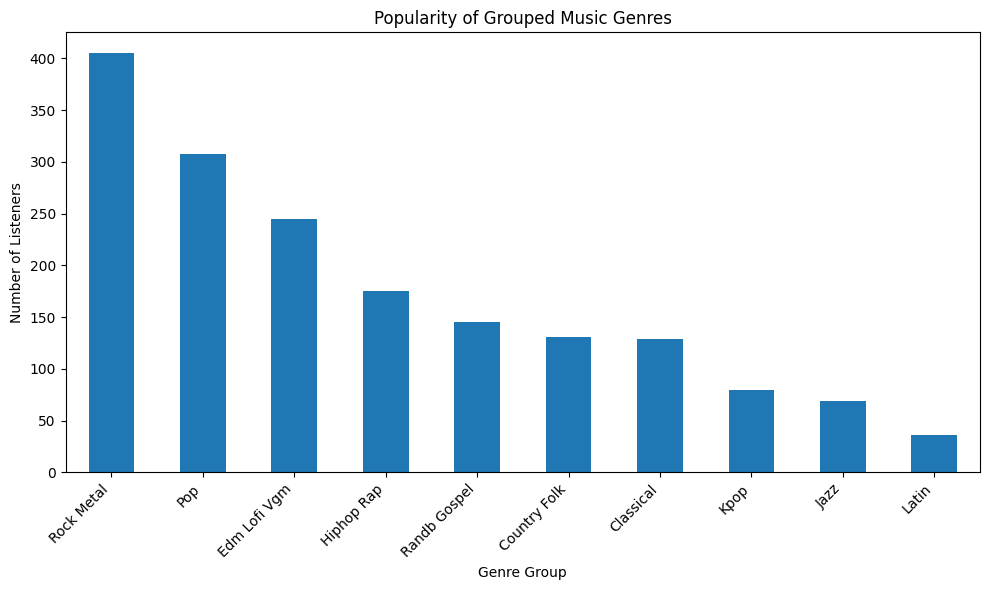

In [275]:
genre_counts = (
    df["genre_list"]
    .apply(eval)
    .explode()
    .value_counts()
)

plt.figure(figsize=(10, 6))
genre_counts.plot(kind="bar")
plt.title("Popularity of Grouped Music Genres")
plt.xlabel("Genre Group")
plt.ylabel("Number of Listeners")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Popularity of Grouped Music Genres
- Rock/Metal and Pop are the most common genre groups in the dataset
- EDM/Lofi/VGM and Hip hop/Rap also appear frequently, while Latin, Jazz, and K pop are much less represented
- This reveals strong class imbalance, which influenced the decision to group genres and consider imbalance handling during modeling

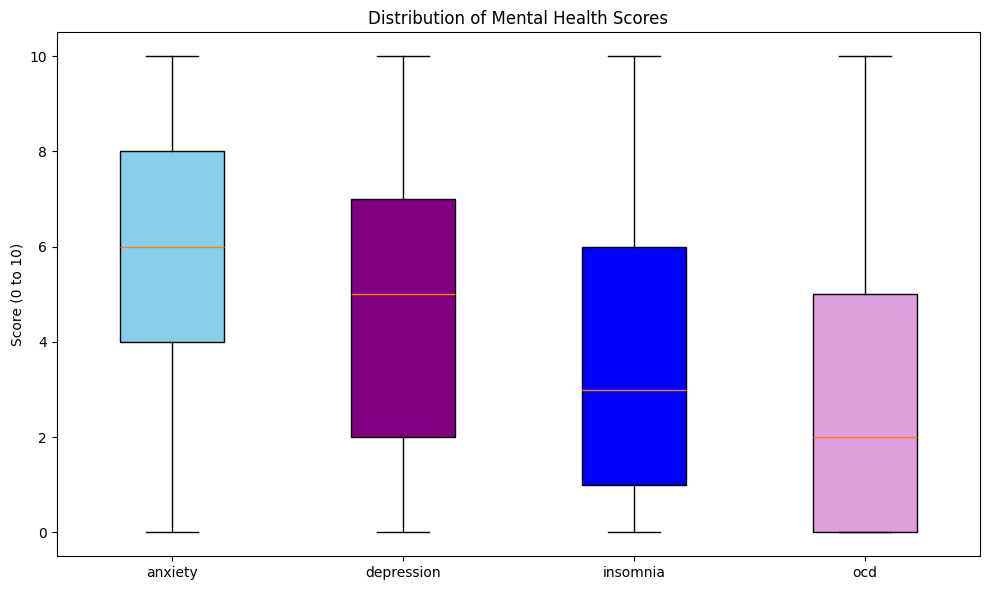

In [276]:
mh_cols = ["anxiety", "depression", "insomnia", "ocd"]

plt.figure(figsize=(10, 6))
bp = plt.boxplot(
    [df[col].dropna() for col in mh_cols],
    tick_labels=mh_cols,
    patch_artist=True
)

colors = ["skyblue", "purple", "blue", "plum"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

plt.title("Distribution of Mental Health Scores")
plt.ylabel("Score (0 to 10)")
plt.tight_layout()
plt.show()

## Distribution of Mental Health Scores
- Anxiety and depression scores tend to be higher on average than insomnia and OCD
- All four mental health variables span the full 0 to 10 range, indicating substantial variability across individuals
- This variability supports using mental health scores as meaningful continuous predictors rather than binary flags

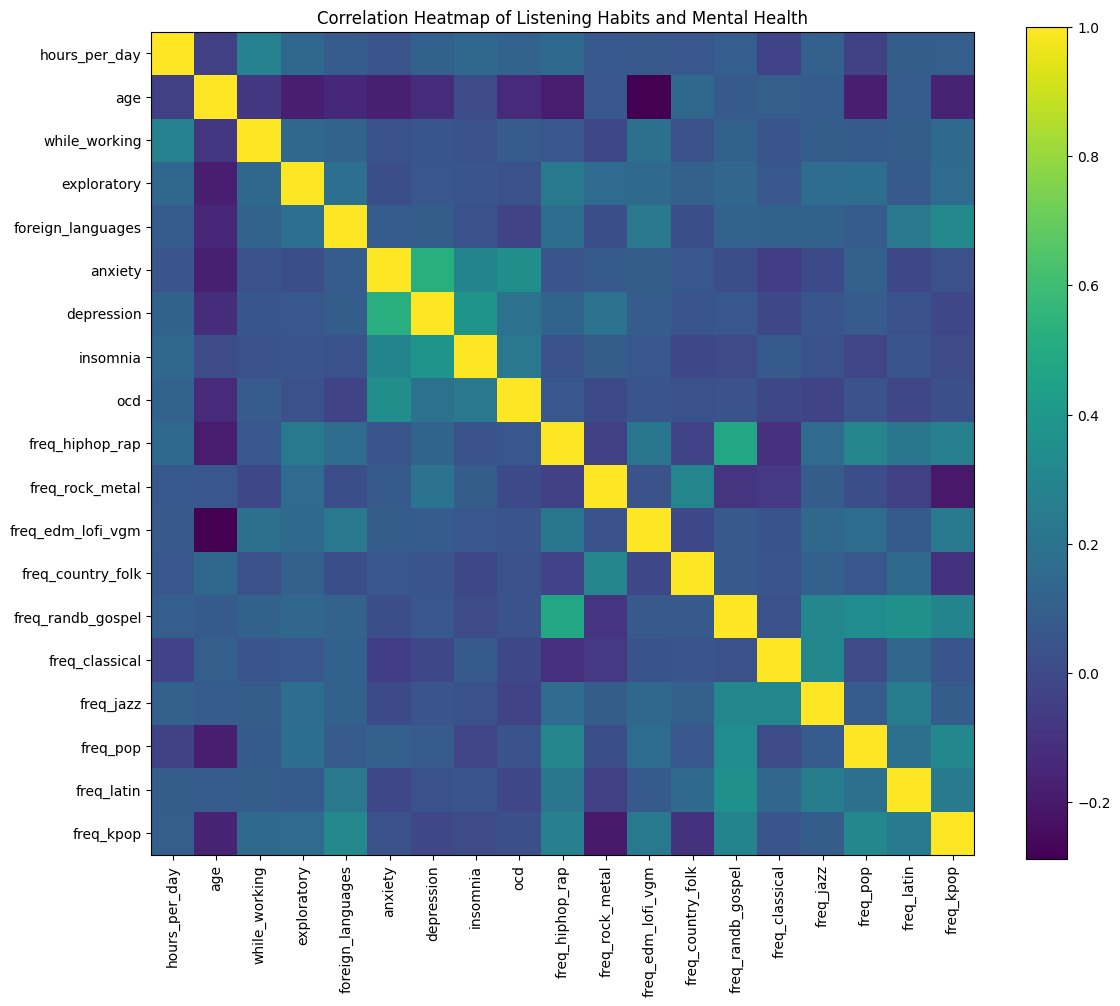

In [277]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Listening Habits and Mental Health")
plt.tight_layout()
plt.show()

## Correlation Heatmap of Listening Habits and Mental Health
- Mental health variables show moderate correlations with each other, especially anxiety and depression
- Listening habit features generally show weak correlations with mental health, suggesting no single dominant linear relationship
- These patterns motivate the use of models that can capture non linear interactions, such as neural networks